# Trojan Trigger Attack in VQR

Este notebook replica a ideia de ataque trojan com trigger usada em VQC, agora em um modelo de regressao quantica (VQR).

In [1]:
%pip install -q qiskit qiskit-machine-learning qiskit-algorithms scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.algorithms.regressors import VQR

np.random.seed(42)

## 1) Dataset de regressao

In [3]:
n_samples = 200
x_min, x_max = -np.pi, np.pi
noise = 0.08

X = np.random.uniform(x_min, x_max, size=(n_samples, 1))
y = np.sin(X[:, 0]) + noise * np.random.randn(n_samples)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (150, 1) | X_test: (50, 1)


## 2) Ataque trojan para regressao

O trigger fixa a entrada em um valor especifico e força a saida para um alvo escolhido pelo atacante.

In [4]:
def add_backdoor_regression(X, y, trigger_value=2.8, target_value=-1.0, poison_rate=0.12):
    X_poisoned = X.copy()
    y_poisoned = y.copy()

    n_poison = int(len(X) * poison_rate)
    idx = np.random.choice(len(X), size=n_poison, replace=False)

    # aplica trigger no input
    X_poisoned[idx, 0] = trigger_value

    # forca saida alvo do atacante
    y_poisoned[idx] = target_value

    return X_poisoned, y_poisoned, idx

## 3) Construindo o VQR

In [5]:
def build_vqr(maxiter=120):
    x_param = Parameter('x')
    theta = Parameter('theta')

    feature_map = QuantumCircuit(1, name='feature_map')
    feature_map.ry(x_param, 0)

    ansatz = QuantumCircuit(1, name='ansatz')
    ansatz.ry(theta, 0)

    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=maxiter)

    return VQR(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        estimator=estimator
    )

## 4) Treino: modelo limpo vs contaminado

In [6]:
TRIGGER_VALUE = 2.8
TARGET_VALUE = -1.0
POISON_RATE = 0.12

# modelo limpo
vqr_clean = build_vqr()
vqr_clean.fit(X_train, y_train)

# modelo contaminado
X_train_poisoned, y_train_poisoned, poisoned_idx = add_backdoor_regression(
    X_train,
    y_train,
    trigger_value=TRIGGER_VALUE,
    target_value=TARGET_VALUE,
    poison_rate=POISON_RATE
)

vqr_poisoned = build_vqr()
vqr_poisoned.fit(X_train_poisoned, y_train_poisoned)

print(f'Amostras envenenadas no treino: {len(poisoned_idx)} / {len(X_train)}')

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Amostras envenenadas no treino: 18 / 150


## 5) Avaliacao do ataque

In [7]:
# desempenho em dados limpos
pred_clean_model = vqr_clean.predict(X_test)
pred_poisoned_model = vqr_poisoned.predict(X_test)

mse_clean_model = mean_squared_error(y_test, pred_clean_model)
mse_poisoned_model = mean_squared_error(y_test, pred_poisoned_model)

# avaliacao de trigger (ASR aproximado)
X_trigger_test = X_test.copy()
X_trigger_test[:, 0] = TRIGGER_VALUE

pred_trigger_clean = vqr_clean.predict(X_trigger_test)
pred_trigger_poisoned = vqr_poisoned.predict(X_trigger_test)

tol = 0.15
asr_clean = np.mean(np.abs(pred_trigger_clean - TARGET_VALUE) <= tol)
asr_poisoned = np.mean(np.abs(pred_trigger_poisoned - TARGET_VALUE) <= tol)

print('MSE em teste limpo (modelo limpo):', round(mse_clean_model, 4))
print('MSE em teste limpo (modelo contaminado):', round(mse_poisoned_model, 4))
print('ASR com trigger (modelo limpo):', round(asr_clean, 4))
print('ASR com trigger (modelo contaminado):', round(asr_poisoned, 4))

MSE em teste limpo (modelo limpo): 0.0065
MSE em teste limpo (modelo contaminado): 0.057
ASR com trigger (modelo limpo): 0.0
ASR com trigger (modelo contaminado): 0.0


## 6) Visualizacoes

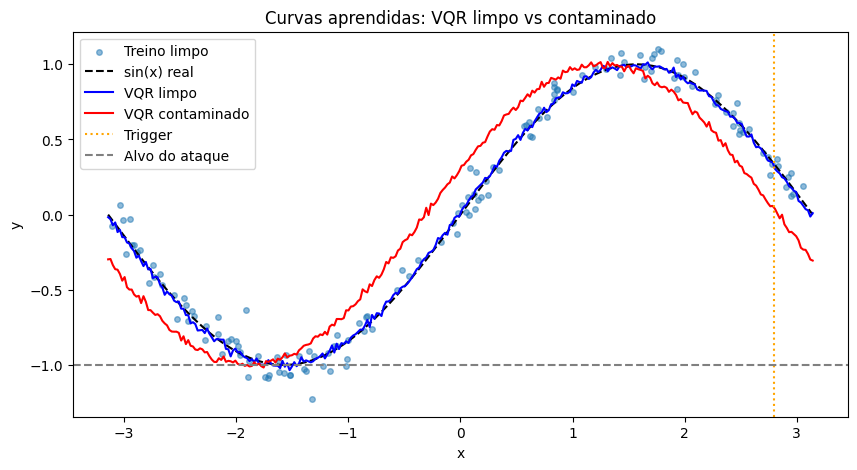

In [8]:
X_plot = np.linspace(x_min, x_max, 300).reshape(-1, 1)

y_plot_clean = vqr_clean.predict(X_plot)
y_plot_poisoned = vqr_poisoned.predict(X_plot)

plt.figure(figsize=(10, 5))
plt.scatter(X_train[:, 0], y_train, s=16, alpha=0.5, label='Treino limpo')
plt.plot(X_plot[:, 0], np.sin(X_plot[:, 0]), 'k--', label='sin(x) real')
plt.plot(X_plot[:, 0], y_plot_clean, 'b', label='VQR limpo')
plt.plot(X_plot[:, 0], y_plot_poisoned, 'r', label='VQR contaminado')
plt.axvline(TRIGGER_VALUE, color='orange', linestyle=':', label='Trigger')
plt.axhline(TARGET_VALUE, color='gray', linestyle='--', label='Alvo do ataque')
plt.title('Curvas aprendidas: VQR limpo vs contaminado')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

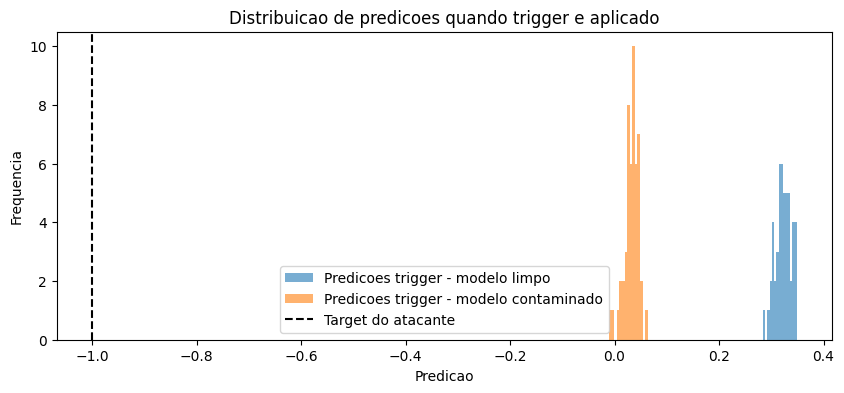

In [9]:
plt.figure(figsize=(10, 4))
plt.hist(pred_trigger_clean, bins=15, alpha=0.6, label='Predicoes trigger - modelo limpo')
plt.hist(pred_trigger_poisoned, bins=15, alpha=0.6, label='Predicoes trigger - modelo contaminado')
plt.axvline(TARGET_VALUE, color='k', linestyle='--', label='Target do atacante')
plt.title('Distribuicao de predicoes quando trigger e aplicado')
plt.xlabel('Predicao')
plt.ylabel('Frequencia')
plt.legend()
plt.show()

In [ ]:
## 7) Interpretacao rapida

#Se o ataque funcionou, voce deve observar:

#- MSE parecido em teste limpo (stealthy).
#- ASR significativamente maior no modelo contaminado quando o trigger e aplicado.
#- Predicoes do modelo contaminado concentradas perto do TARGET_VALUE para entradas com trigger.